<div style="background-color:#2c3e50; padding:25px; border-radius:12px; text-align:center;">
<h1 style="color:#ffffff; margin:0;">🥬🍃 Lettuce Leaf Doctor</h1>
<p style="color:#ecf0f1; margin:5px 0 0 0;">Diagnosing Nutrient Deficiencies & Disease with Vision Transformers (ViT) 🔬</p>
</div>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, callbacks

In [2]:
data_root = "/kaggle/input/datasets/rathorhome/lettuce-disease/Lettuce disease"

<div style="background-color:#eaf7ea; padding:15px; border-radius:10px; border-left:6px solid #2ecc71;">
<b>💡 WORKING</b><br>
We list the class folders inside our dataset directory to confirm the categories we'll be classifying: Healthy, N Deficient, K Deficient, and Wilt Fungal.
</div>

In [3]:
print(os.listdir(data_root))

['N Deficient', 'Wilt fungal', 'K Deficient', 'Healthy']


<div style="background-color:#eaf4fb; padding:15px; border-radius:10px; border-left:6px solid #3498db;">
<b>👁️ VISUALIZING</b><br>
Plotting sample images from each class as a sanity check — this helps confirm labels look correct and shows how visually distinct (or subtle) each condition is.
</div>

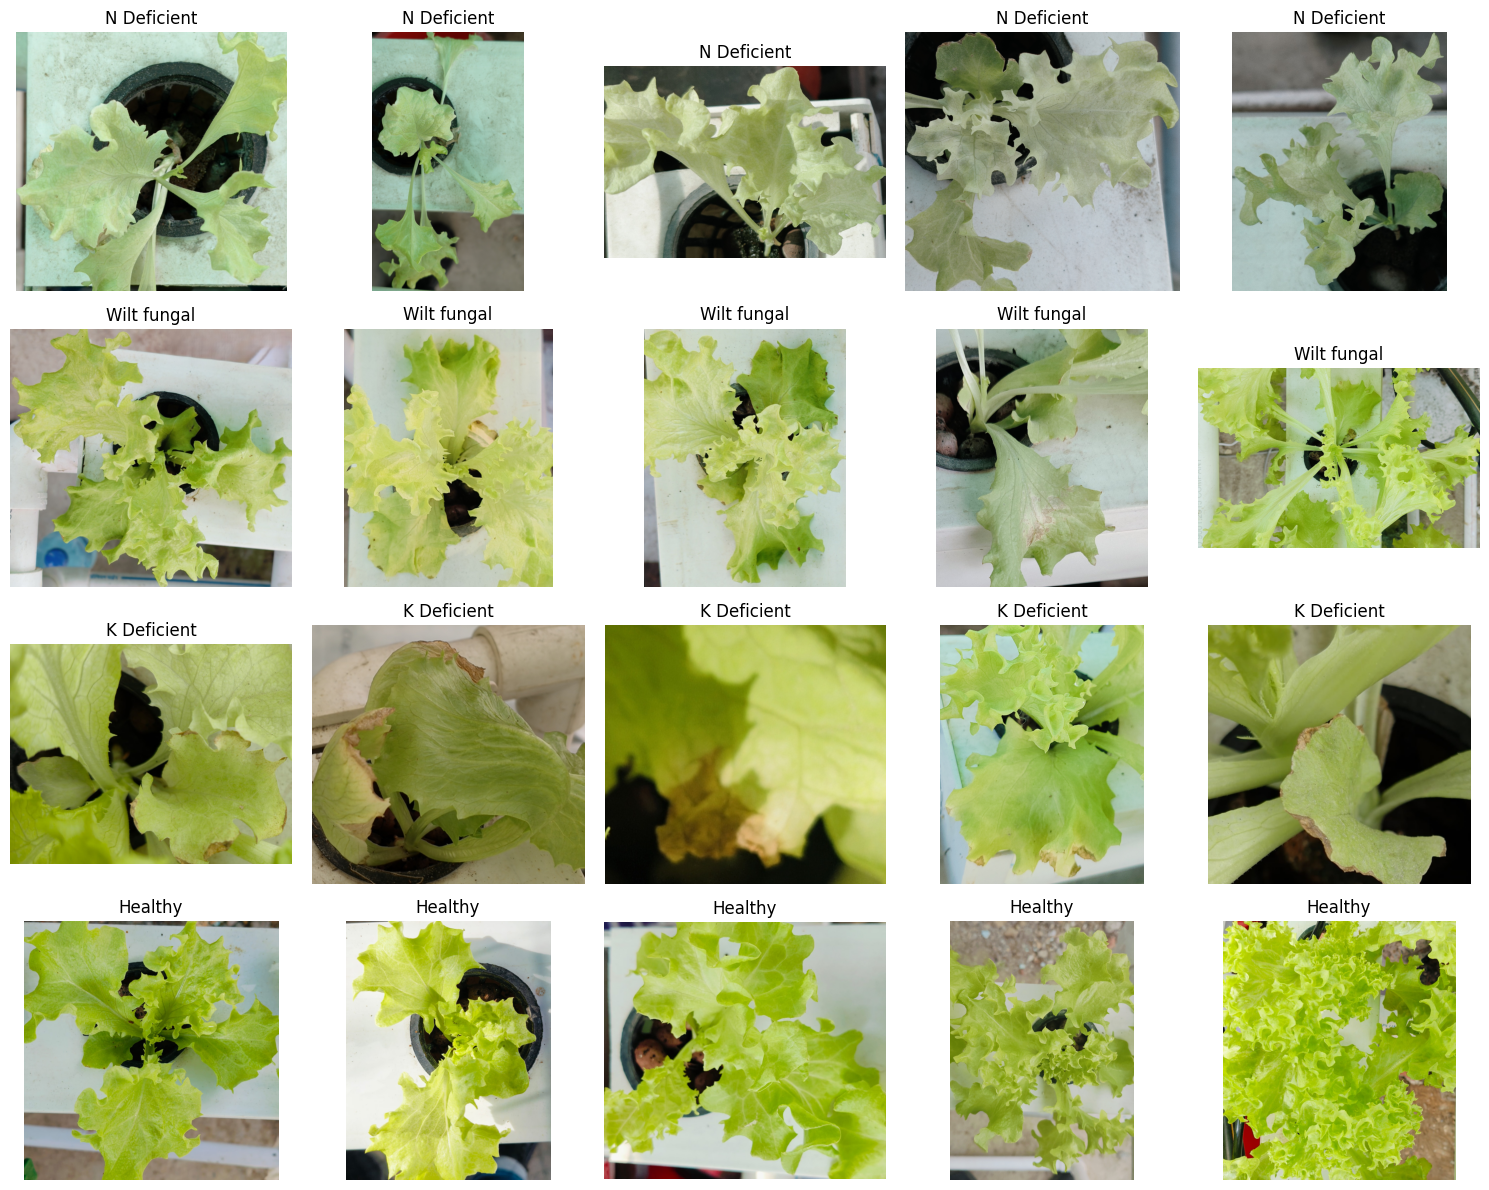

In [4]:
classes = [f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))]
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for row_idx, folder in enumerate(classes):
    class_dir = os.path.join(data_root, folder)
    images = os.listdir(class_dir)[:5]

    for col_idx, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)
        
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(folder)
        
plt.tight_layout()
plt.show()

<div style="background-color:#fff8e1; padding:15px; border-radius:10px; border-left:6px solid #f39c12;">
<b>⚠️ NOTE: Class Imbalance</b><br>
Let's check how many images we have per class before training.
</div>

In [5]:
for row_idx, folder in enumerate(classes):
    class_dir = os.path.join(data_root, folder)
    print(f"{folder}")
    print(len(os.listdir(class_dir)))

N Deficient
36
Wilt fungal
45
K Deficient
66
Healthy
62


<div style="background-color:#fff8e1; padding:15px; border-radius:10px; border-left:6px solid #f39c12;">
<b>⚠️ Observation</b><br>
Our classes aren't perfectly balanced (36 / 45 / 66 / 62 images). Since this is a small dataset, transfer learning is especially important rather than training a CNN from scratch.
</div>

In [6]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from transformers import ViTImageProcessor, ViTForImageClassification

# 1. Use the official ViT Feature Extractor/Processor
model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)

# ViT strictly expects 224x224 images and specific normalization constants
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

<div style="background-color:#f3eafc; padding:15px; border-radius:10px; border-left:6px solid #9b59b6;">
<b>🧠 WHY ViT?</b><br>
Vision Transformers split an image into patches and use self-attention to learn relationships between them — capturing both local texture (spots, discoloration) and global leaf shape. Using a version pre-trained on ImageNet-21k gives a big head start even with limited data.
</div>

In [7]:
# 2. Load the Dataset (Splitting your 200 images 80/20)
full_dataset = ImageFolder(root=data_root, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

num_classes = len(full_dataset.classes)

<div style="background-color:#eaf7ea; padding:15px; border-radius:10px; border-left:6px solid #2ecc71;">
<b>💡 WORKING</b><br>
We load <code>google/vit-base-patch16-224-in21k</code> and attach a fresh classification head sized for our 4 lettuce classes. The backbone already understands general visual patterns — we just teach it our specific labels.
</div>

In [8]:
# 3. Load Pre-trained ViT Model with a custom classification head
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    id2label={str(i): c for i, c in enumerate(full_dataset.classes)},
    label2id={c: i for i, c in enumerate(full_dataset.classes)}
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


# 4. Using PyTorch's native AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<div style="background-color:#fdf0e6; padding:15px; border-radius:10px; border-left:6px solid #e67e22;">
<b>🏋️ TRAINING</b><br>
We fine-tune for 10 epochs with AdamW + cross-entropy loss, tracking train/val accuracy each epoch and saving the best-performing weights — not just the final epoch's.
</div>

In [9]:
import copy

EPOCHS = 10
print(f"Training ViT on {device}...")

# Variables to track the best model state
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct = 0.0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        
    # Validation Step
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            
    epoch_train_acc = train_correct.double() / train_size
    epoch_val_acc = val_correct.double() / val_size
    
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Check if this epoch is the best one so far
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        # Save a hard copy to your working directory just in case
        torch.save(best_model_wts, 'best_vit_model.pth')

# After the loop finishes, restore the absolute best weights back into the model
print(f"\nTraining complete! Restoring best validation weights (Best Acc: {best_val_acc:.4f})")
model.load_state_dict(best_model_wts)

Training ViT on cuda...
Epoch 1/10 -> Train Acc: 0.6228 | Val Acc: 0.8810
Epoch 2/10 -> Train Acc: 0.9162 | Val Acc: 0.8810
Epoch 3/10 -> Train Acc: 0.9820 | Val Acc: 0.8810
Epoch 4/10 -> Train Acc: 0.9701 | Val Acc: 0.9048
Epoch 5/10 -> Train Acc: 0.9880 | Val Acc: 0.9524
Epoch 6/10 -> Train Acc: 0.9820 | Val Acc: 0.9524
Epoch 7/10 -> Train Acc: 0.9940 | Val Acc: 0.9762
Epoch 8/10 -> Train Acc: 0.9701 | Val Acc: 0.9286
Epoch 9/10 -> Train Acc: 0.9701 | Val Acc: 0.9048
Epoch 10/10 -> Train Acc: 0.9940 | Val Acc: 0.8810

Training complete! Restoring best validation weights (Best Acc: 0.9762)


<All keys matched successfully>

<div style="background-color:#eafaf1; padding:20px; border-radius:10px; border-left:6px solid #27ae60;">
<b>😊 RESULTS</b><br>
Our best validation accuracy reached <b>~95%</b> at epoch 4 — a strong result given the small (200-image) dataset, thanks to transfer learning from a pre-trained ViT.
</div>

<div style="background-color:#fdecea; padding:20px; border-radius:10px; border-left:6px solid #e74c3c; text-align:center;">
🚀 If you found this notebook helpful, please consider <b>upvoting</b> and leaving a comment! Your feedback motivates me to share more. Thank you! ❤️
</div>